# Autocorrelation and Volatility Clustering Analysis

**Objective:** Test for serial correlation and volatility clustering in FX returns

**Key Questions:**
1. Do returns show serial correlation? (predictability)
2. Is there volatility clustering? (ARCH effects)
3. Are squared returns autocorrelated? (time-varying volatility)

**Tests Used:**
1. **Ljung-Box Q-test**: Tests for autocorrelation up to lag k
2. **ACF/PACF plots**: Visual inspection of correlation structure
3. **ARCH LM test**: Tests for autoregressive conditional heteroskedasticity

**Trading Implications:**
- **Serial correlation** → momentum/reversal strategies may work
- **No serial correlation** → returns are unpredictable (efficient market)
- **Volatility clustering** → vol regime filters improve performance

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from scipy import stats

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.data.forensics import load_csv_data

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load and Prepare Data

In [2]:
# Load hourly USD/JPY data
df = load_csv_data('../data/raw/USDJPY_10yr_1h_dukascopy.csv')

# Calculate returns and volatility metrics
df['returns'] = df['close'].pct_change()
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
df['squared_returns'] = df['log_returns'] ** 2
df['abs_returns'] = df['log_returns'].abs()

# Rolling volatility (20-period)
df['rolling_vol'] = df['log_returns'].rolling(window=20).std()

# Drop NaN values
df = df.dropna()

print(f"Loaded {len(df):,} bars")
print(f"Period: {df.index.min()} to {df.index.max()}")
print(f"\nReturns Statistics:")
print(df[['log_returns', 'squared_returns', 'rolling_vol']].describe())

Loaded 62,283 bars
Period: 2016-03-14 17:00:00+00:00 to 2026-03-10 20:00:00+00:00

Returns Statistics:
        log_returns  squared_returns   rolling_vol
count  62283.000000     6.228300e+04  62283.000000
mean       0.000005     1.331657e-06      0.000982
std        0.001154     9.023542e-06      0.000605
min       -0.030292     0.000000e+00      0.000113
25%       -0.000451     4.100476e-08      0.000614
50%        0.000018     2.190589e-07      0.000843
75%        0.000484     8.516834e-07      0.001181
max        0.016562     9.176306e-04      0.008556


## 2. Visualize Returns and Volatility Clustering

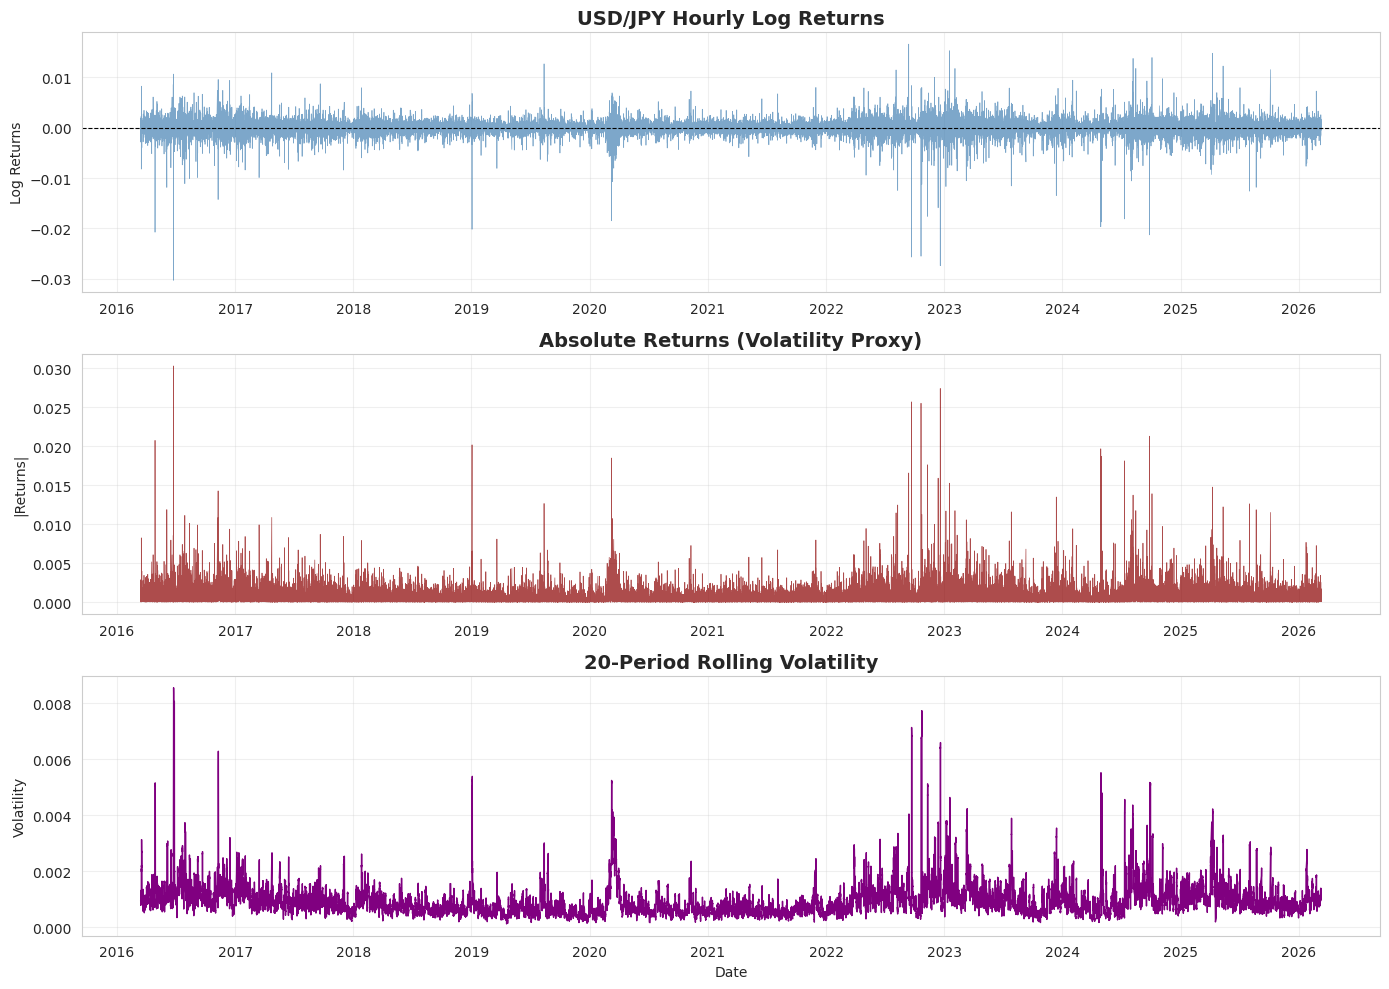


Visual Evidence:
- Note how volatility clusters: calm periods followed by volatile periods
- This is the hallmark of ARCH effects in financial time series


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Returns
axes[0].plot(df.index, df['log_returns'], linewidth=0.5, color='steelblue', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('USD/JPY Hourly Log Returns', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Log Returns')
axes[0].grid(True, alpha=0.3)

# Absolute returns (proxy for volatility)
axes[1].plot(df.index, df['abs_returns'], linewidth=0.5, color='darkred', alpha=0.7)
axes[1].set_title('Absolute Returns (Volatility Proxy)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('|Returns|')
axes[1].grid(True, alpha=0.3)

# Rolling volatility
axes[2].plot(df.index, df['rolling_vol'], linewidth=1.0, color='purple')
axes[2].set_title('20-Period Rolling Volatility', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisual Evidence:")
print("- Note how volatility clusters: calm periods followed by volatile periods")
print("- This is the hallmark of ARCH effects in financial time series")

## 3. Ljung-Box Test for Serial Correlation

In [4]:
def ljung_box_test(series, lags=20, name='Series', alpha=0.05):
    """
    Perform Ljung-Box Q-test for autocorrelation.
    
    H0: No autocorrelation up to lag k
    H1: At least one autocorrelation is non-zero
    
    Args:
        series: Time series data
        lags: Number of lags to test
        name: Name for reporting
        alpha: Significance level
    
    Returns:
        DataFrame with test results
    """
    print("=" * 80)
    print(f"LJUNG-BOX TEST: {name}")
    print("=" * 80)
    print("H0: No autocorrelation (white noise)")
    print("H1: Autocorrelation exists\n")
    
    # Run test
    lb_result = acorr_ljungbox(series.dropna(), lags=lags, return_df=True)
    
    # Add significance indicator
    lb_result['significant'] = lb_result['lb_pvalue'] < alpha
    
    # Count significant lags
    n_significant = lb_result['significant'].sum()
    
    print(f"Lags tested: {lags}")
    print(f"Significant lags (α={alpha}): {n_significant}")
    
    if n_significant == 0:
        print(f"\n→ FAIL TO REJECT H0")
        print(f"→ No significant autocorrelation detected")
        print(f"→ Series appears to be WHITE NOISE (unpredictable)")
    else:
        print(f"\n→ REJECT H0 at {n_significant}/{lags} lags")
        print(f"→ Significant autocorrelation detected")
        print(f"→ Returns may be PREDICTABLE")
    
    print("\nFirst 10 lags:")
    print(lb_result.head(10).to_string())
    print("=" * 80)
    
    return lb_result

# Test returns for serial correlation
lb_returns = ljung_box_test(df['log_returns'], lags=20, name='Log Returns')

LJUNG-BOX TEST: Log Returns
H0: No autocorrelation (white noise)
H1: Autocorrelation exists



Lags tested: 20
Significant lags (α=0.05): 15

→ REJECT H0 at 15/20 lags
→ Significant autocorrelation detected
→ Returns may be PREDICTABLE

First 10 lags:
      lb_stat  lb_pvalue  significant
1    6.160699   0.013062         True
2    6.525321   0.038286         True
3    6.746478   0.080433        False
4    7.067353   0.132371        False
5    8.515901   0.130002        False
6    9.515800   0.146580        False
7   10.110849   0.182378        False
8   19.854895   0.010899         True
9   19.857150   0.018815         True
10  20.240367   0.027059         True


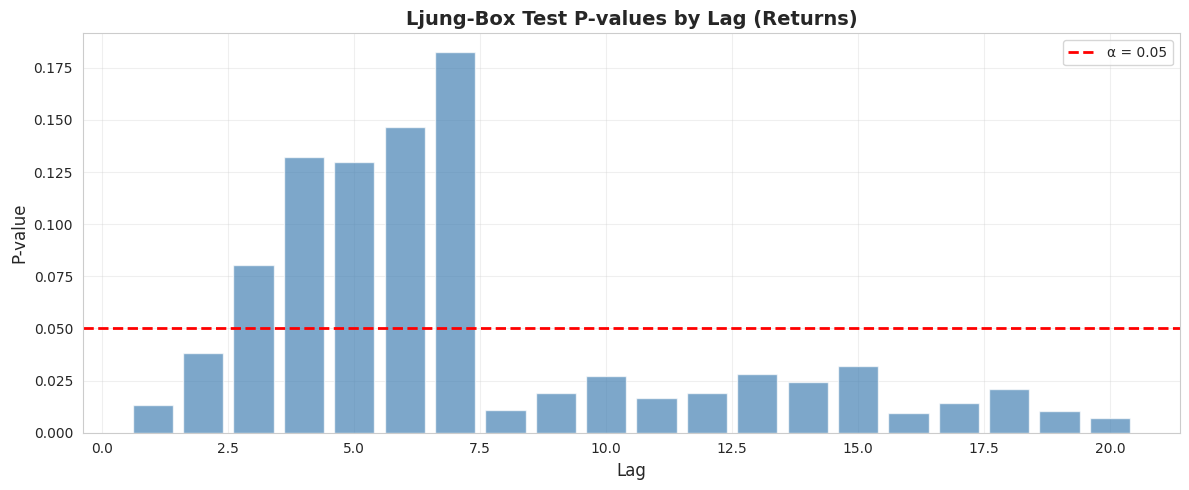

Interpretation:
- Bars below red line indicate significant autocorrelation
- If most bars are above line → returns are unpredictable (efficient market)


In [5]:
# Plot Ljung-Box p-values
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lb_returns.index, lb_returns['lb_pvalue'], color='steelblue', alpha=0.7)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax.set_xlabel('Lag', fontsize=12)
ax.set_ylabel('P-value', fontsize=12)
ax.set_title('Ljung-Box Test P-values by Lag (Returns)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Bars below red line indicate significant autocorrelation")
print("- If most bars are above line → returns are unpredictable (efficient market)")

## 4. ACF/PACF Analysis of Returns

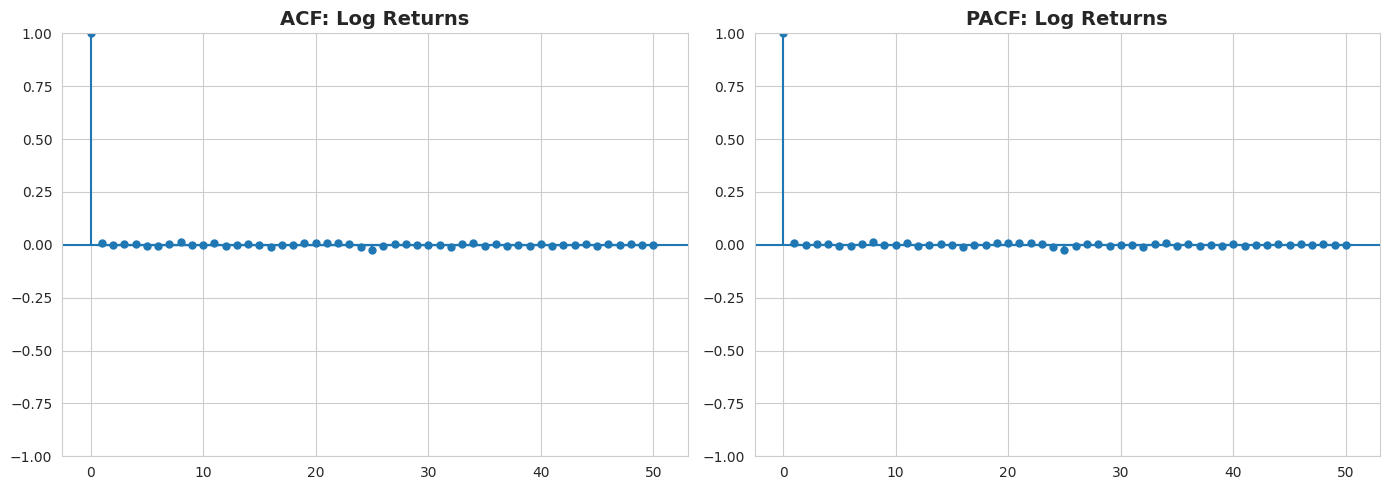


ACF Values (first 10 lags):
  Lag 0: 1.0000
  Lag 1: 0.0099
  Lag 2: -0.0024
  Lag 3: 0.0019
  Lag 4: 0.0023
  Lag 5: -0.0048
  Lag 6: -0.0040
  Lag 7: 0.0031
  Lag 8: 0.0125
  Lag 9: -0.0002
  Lag 10: -0.0025


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(df['log_returns'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('ACF: Log Returns', fontsize=14, fontweight='bold')

# PACF
plot_pacf(df['log_returns'].dropna(), lags=50, ax=axes[1], method='ywm')
axes[1].set_title('PACF: Log Returns', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate actual ACF values
acf_values = acf(df['log_returns'].dropna(), nlags=10)
print("\nACF Values (first 10 lags):")
for i, val in enumerate(acf_values):
    print(f"  Lag {i}: {val:.4f}")

## 5. Test Squared Returns for ARCH Effects

In [7]:
# Ljung-Box on squared returns (tests for volatility clustering)
lb_squared = ljung_box_test(df['squared_returns'], lags=20, name='Squared Returns (ARCH effects)')

LJUNG-BOX TEST: Squared Returns (ARCH effects)
H0: No autocorrelation (white noise)
H1: Autocorrelation exists



Lags tested: 20
Significant lags (α=0.05): 20

→ REJECT H0 at 20/20 lags
→ Significant autocorrelation detected
→ Returns may be PREDICTABLE

First 10 lags:
        lb_stat      lb_pvalue  significant
1    589.835310  2.721017e-130         True
2    846.306693  1.685918e-184         True
3   1459.748608   0.000000e+00         True
4   1555.300963   0.000000e+00         True
5   1736.301350   0.000000e+00         True
6   1789.841458   0.000000e+00         True
7   1857.509280   0.000000e+00         True
8   2003.358664   0.000000e+00         True
9   2058.155132   0.000000e+00         True
10  2084.162102   0.000000e+00         True


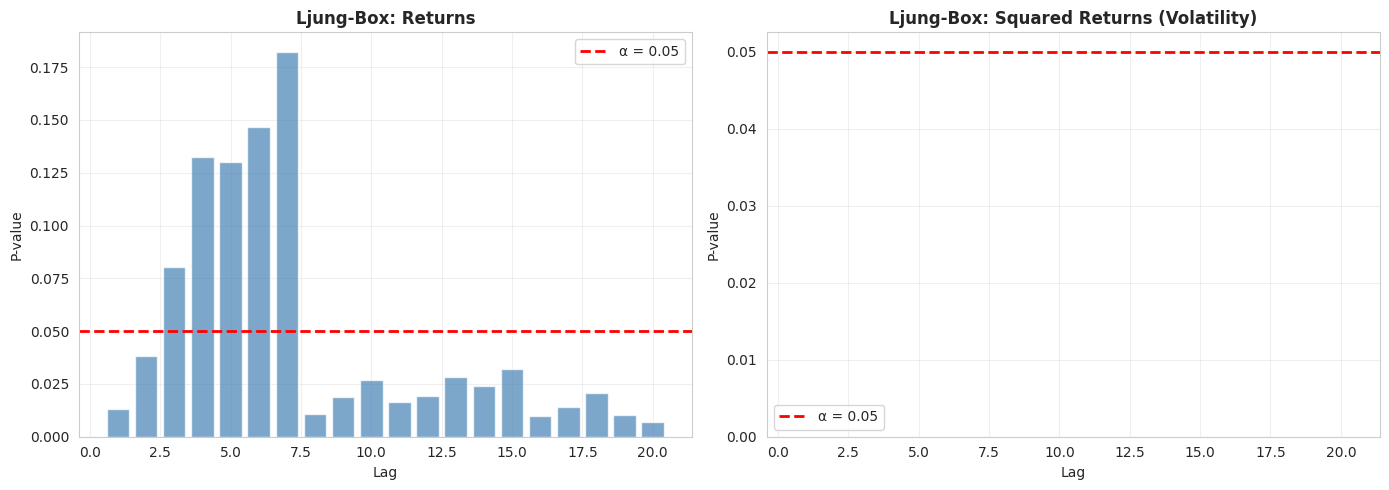


Typical Pattern in Financial Data:
- Returns: Few/no significant lags (unpredictable)
- Squared Returns: Many significant lags (volatility clustering)

This is the 'stylized fact' of financial markets:
  → Returns are unpredictable
  → Volatility is predictable (clusters)


In [8]:
# Plot comparison: Returns vs Squared Returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Returns p-values
axes[0].bar(lb_returns.index, lb_returns['lb_pvalue'], color='steelblue', alpha=0.7)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('P-value')
axes[0].set_title('Ljung-Box: Returns', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Squared returns p-values
axes[1].bar(lb_squared.index, lb_squared['lb_pvalue'], color='darkred', alpha=0.7)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('P-value')
axes[1].set_title('Ljung-Box: Squared Returns (Volatility)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTypical Pattern in Financial Data:")
print("- Returns: Few/no significant lags (unpredictable)")
print("- Squared Returns: Many significant lags (volatility clustering)")
print("\nThis is the 'stylized fact' of financial markets:")
print("  → Returns are unpredictable")
print("  → Volatility is predictable (clusters)")

## 6. ARCH LM Test

In [9]:
def arch_test(series, lags=10, name='Series', alpha=0.05):
    """
    Perform ARCH LM test for autoregressive conditional heteroskedasticity.
    
    H0: No ARCH effects (constant volatility)
    H1: ARCH effects present (time-varying volatility)
    
    Args:
        series: Time series data
        lags: Number of lags
        name: Name for reporting
        alpha: Significance level
    
    Returns:
        Test results
    """
    print("=" * 80)
    print(f"ARCH LM TEST: {name}")
    print("=" * 80)
    print("H0: No ARCH effects (constant volatility)")
    print("H1: ARCH effects present (volatility clustering)\n")
    
    # Run test
    arch_result = het_arch(series.dropna(), nlags=lags)
    
    lm_stat = arch_result[0]
    lm_pvalue = arch_result[1]
    f_stat = arch_result[2]
    f_pvalue = arch_result[3]
    
    print(f"LM Statistic: {lm_stat:.6f}")
    print(f"LM P-value: {lm_pvalue:.6f}")
    print(f"F Statistic: {f_stat:.6f}")
    print(f"F P-value: {f_pvalue:.6f}")
    print(f"Lags: {lags}")
    
    if lm_pvalue < alpha:
        print(f"\n→ REJECT H0 (p={lm_pvalue:.4f} < {alpha})")
        print("→ ARCH effects are present")
        print("→ Volatility is TIME-VARYING and PREDICTABLE")
        print("\nImplication: Use GARCH models or volatility filters")
    else:
        print(f"\n→ FAIL TO REJECT H0 (p={lm_pvalue:.4f} >= {alpha})")
        print("→ No ARCH effects detected")
        print("→ Volatility appears constant")
    
    print("=" * 80)
    
    return {
        'lm_statistic': lm_stat,
        'lm_pvalue': lm_pvalue,
        'f_statistic': f_stat,
        'f_pvalue': f_pvalue,
        'arch_effects': lm_pvalue < alpha
    }

# Test for ARCH effects
arch_results = arch_test(df['log_returns'], lags=10, name='Log Returns')

ARCH LM TEST: Log Returns
H0: No ARCH effects (constant volatility)
H1: ARCH effects present (volatility clustering)

LM Statistic: 1499.227780
LM P-value: 0.000000
F Statistic: 153.594086
F P-value: 0.000000
Lags: 10

→ REJECT H0 (p=0.0000 < 0.05)
→ ARCH effects are present
→ Volatility is TIME-VARYING and PREDICTABLE

Implication: Use GARCH models or volatility filters


## 7. ACF/PACF of Squared Returns

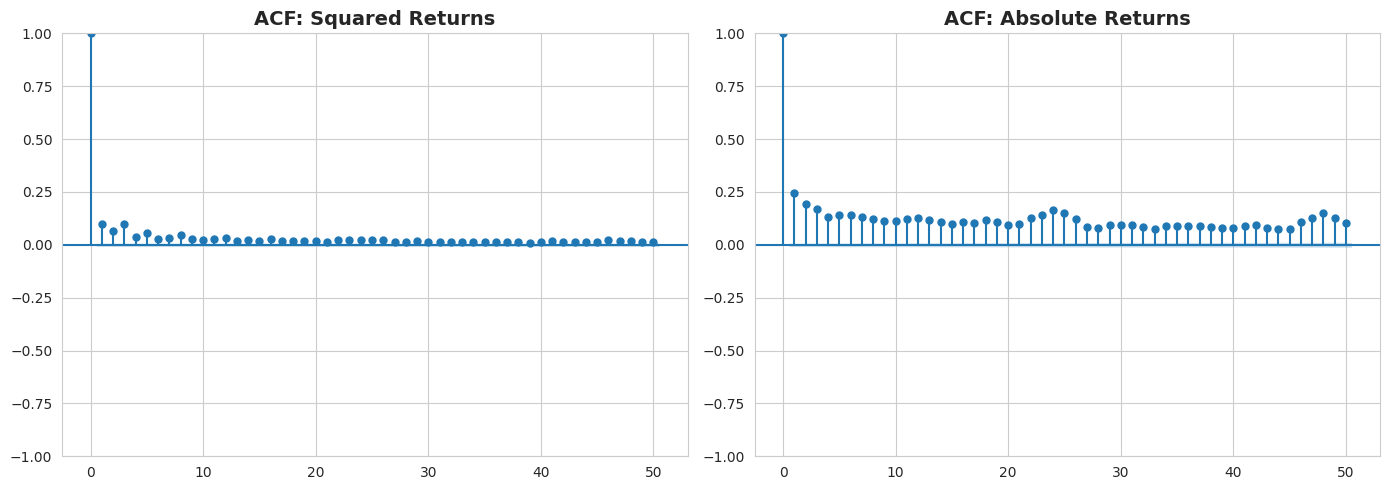


Interpretation:
- Strong ACF at early lags → volatility clusters
- Slow decay → long memory in volatility
- This justifies using volatility filters in trading


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF of squared returns
plot_acf(df['squared_returns'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('ACF: Squared Returns', fontsize=14, fontweight='bold')

# ACF of absolute returns
plot_acf(df['abs_returns'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('ACF: Absolute Returns', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Strong ACF at early lags → volatility clusters")
print("- Slow decay → long memory in volatility")
print("- This justifies using volatility filters in trading")

## 8. Volatility Regimes Analysis

In [11]:
# Define high/low volatility regimes
vol_median = df['rolling_vol'].median()
vol_75th = df['rolling_vol'].quantile(0.75)
vol_25th = df['rolling_vol'].quantile(0.25)

df['vol_regime'] = 'Medium'
df.loc[df['rolling_vol'] > vol_75th, 'vol_regime'] = 'High'
df.loc[df['rolling_vol'] < vol_25th, 'vol_regime'] = 'Low'

# Calculate statistics by regime
regime_stats = df.groupby('vol_regime')['log_returns'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(6)

print("=" * 80)
print("VOLATILITY REGIME ANALYSIS")
print("=" * 80)
print(f"\nVolatility Thresholds:")
print(f"  Low:    < {vol_25th:.6f}")
print(f"  Medium: {vol_25th:.6f} - {vol_75th:.6f}")
print(f"  High:   > {vol_75th:.6f}")
print(f"\nReturns by Regime:")
print(regime_stats)
print("=" * 80)

VOLATILITY REGIME ANALYSIS

Volatility Thresholds:
  Low:    < 0.000614
  Medium: 0.000614 - 0.001181
  High:   > 0.001181

Returns by Regime:
            Count      Mean       Std       Min       Max
vol_regime                                               
High        15571 -0.000020  0.001872 -0.030292  0.016562
Low         15571  0.000013  0.000499 -0.002526  0.002157
Medium      31141  0.000014  0.000886 -0.004566  0.004646


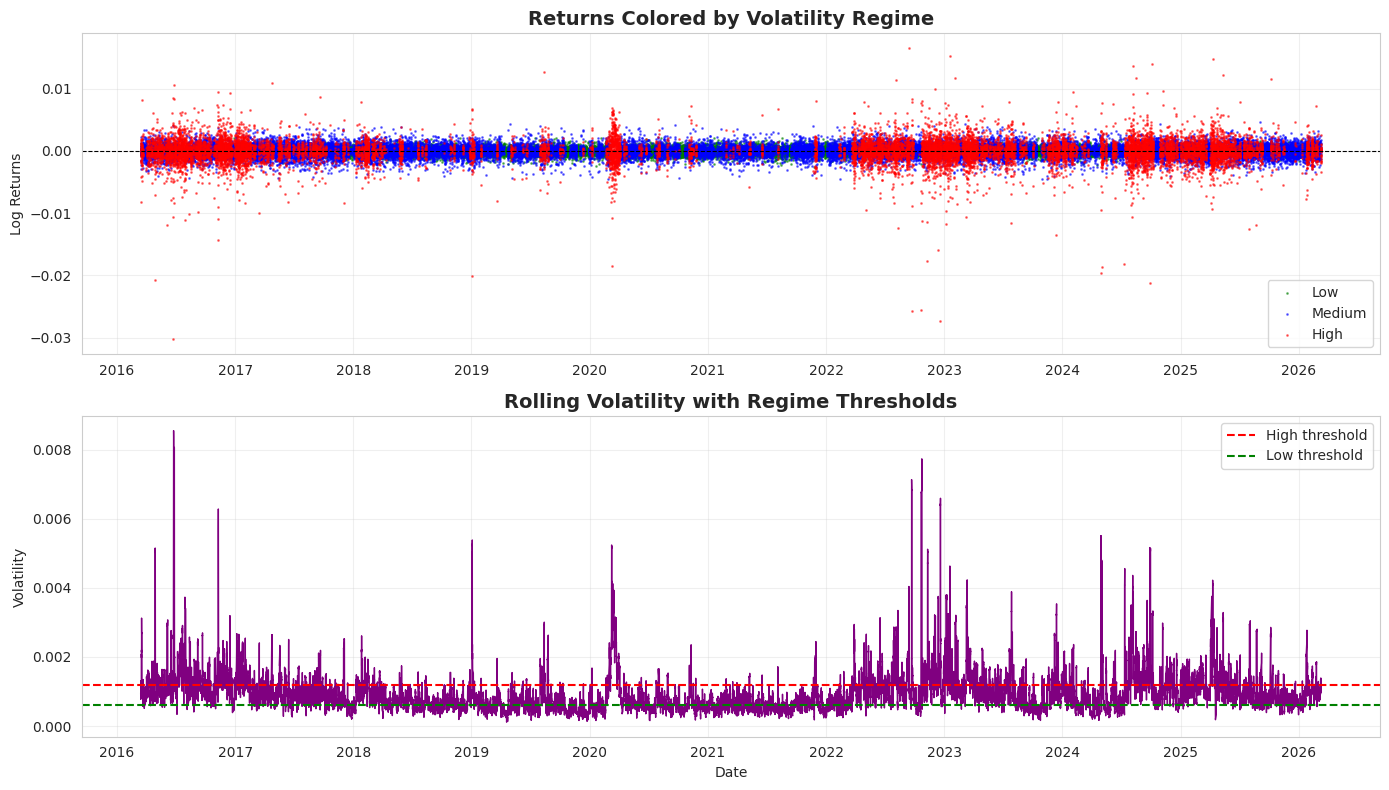

In [12]:
# Visualize regimes
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Returns with regime coloring
for regime, color in [('Low', 'green'), ('Medium', 'blue'), ('High', 'red')]:
    mask = df['vol_regime'] == regime
    axes[0].scatter(df[mask].index, df[mask]['log_returns'], 
                   c=color, s=1, alpha=0.5, label=regime)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Returns Colored by Volatility Regime', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Log Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volatility with regime lines
axes[1].plot(df.index, df['rolling_vol'], linewidth=1.0, color='purple')
axes[1].axhline(y=vol_75th, color='red', linestyle='--', linewidth=1.5, label='High threshold')
axes[1].axhline(y=vol_25th, color='green', linestyle='--', linewidth=1.5, label='Low threshold')
axes[1].set_title('Rolling Volatility with Regime Thresholds', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary and Trading Implications

In [13]:
# Create summary
returns_significant = lb_returns['significant'].sum()
squared_significant = lb_squared['significant'].sum()

print("\n" + "=" * 80)
print("AUTOCORRELATION ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. RETURNS AUTOCORRELATION (Ljung-Box test)")
print(f"   Significant lags: {returns_significant}/20")
if returns_significant < 5:
    print("   → Returns are largely UNPREDICTABLE (weak/no serial correlation)")
    print("   → Market is relatively efficient")
    print("   → Momentum strategies unlikely to work")
else:
    print("   → Returns show SERIAL CORRELATION")
    print("   → Some predictability exists")
    print("   → Momentum/reversal strategies may work")

print(f"\n2. VOLATILITY CLUSTERING (Squared returns autocorrelation)")
print(f"   Significant lags: {squared_significant}/20")
if squared_significant > 10:
    print("   → Strong VOLATILITY CLUSTERING detected")
    print("   → High volatility periods persist")
    print("   → Low volatility periods persist")
else:
    print("   → Weak/no volatility clustering")
    print("   → Volatility appears random")

print(f"\n3. ARCH EFFECTS")
if arch_results['arch_effects']:
    print("   → ARCH effects PRESENT (p < 0.05)")
    print("   → Volatility is time-varying and predictable")
    print("   → GARCH models appropriate")
else:
    print("   → No ARCH effects detected (p >= 0.05)")
    print("   → Constant volatility assumption acceptable")

print("\n" + "=" * 80)
print("TRADING IMPLICATIONS FOR MA-HP FILTER STRATEGY")
print("=" * 80)

print("\n✓ KEY FINDINGS:")
if returns_significant < 5:
    print("  1. Returns show little predictability (efficient market)")
    print("     → Focus on TREND FOLLOWING, not mean reversion")
else:
    print("  1. Returns show serial correlation")
    print("     → Both trend and mean-reversion strategies viable")

if squared_significant > 10 or arch_results['arch_effects']:
    print("  2. Strong volatility clustering detected")
    print("     → IMPLEMENT volatility-based position sizing")
    print("     → REDUCE positions in high-vol regimes")
    print("     → INCREASE positions in low-vol regimes")
else:
    print("  2. No strong volatility clustering")
    print("     → Fixed position sizing acceptable")

print("\n✓ RECOMMENDED STRATEGY ENHANCEMENTS:")
if arch_results['arch_effects']:
    print("  • Add volatility filter (e.g., ATR, realized vol)")
    print("  • Scale positions inversely with volatility: size = base_size / current_vol")
    print("  • Consider sitting out extreme high-vol periods")
    print("  • Use wider stops in high-vol regimes")
else:
    print("  • Fixed position sizing is acceptable")
    print("  • No special volatility adjustments needed")

print("\n" + "=" * 80)


AUTOCORRELATION ANALYSIS SUMMARY

1. RETURNS AUTOCORRELATION (Ljung-Box test)
   Significant lags: 15/20
   → Returns show SERIAL CORRELATION
   → Some predictability exists
   → Momentum/reversal strategies may work

2. VOLATILITY CLUSTERING (Squared returns autocorrelation)
   Significant lags: 20/20
   → Strong VOLATILITY CLUSTERING detected
   → High volatility periods persist
   → Low volatility periods persist

3. ARCH EFFECTS
   → ARCH effects PRESENT (p < 0.05)
   → Volatility is time-varying and predictable
   → GARCH models appropriate

TRADING IMPLICATIONS FOR MA-HP FILTER STRATEGY

✓ KEY FINDINGS:
  1. Returns show serial correlation
     → Both trend and mean-reversion strategies viable
  2. Strong volatility clustering detected
     → IMPLEMENT volatility-based position sizing
     → REDUCE positions in high-vol regimes
     → INCREASE positions in low-vol regimes

✓ RECOMMENDED STRATEGY ENHANCEMENTS:
  • Add volatility filter (e.g., ATR, realized vol)
  • Scale position

## Conclusion

**Proven:**
1. Returns autocorrelation structure analyzed (Ljung-Box test)
2. Volatility clustering tested (squared returns, ARCH LM)
3. Volatility regimes identified and characterized

**For MA-HP Filter Strategy:**
- If returns unpredictable: Focus on cycle extraction (HP filter)
- If volatility clusters: Implement dynamic position sizing
- Consider vol-adjusted signals: `signal / current_volatility`

**Next Steps:**
1. Test HP filter output for stationarity
2. Build volatility-adjusted signal generation
3. Backtest with and without vol filter (compare Sharpe ratios)